# Excersize 
Deep Learning is not "magic" it is Linear Algebra and Calculus optimized for execution on silicon. To build a neural network, you must first understand the relationship between input vectors, weight matrices, and the cost function surface.

# Ex01.
  Let $X \in \mathbb{R}^{m \times n}$ be our design matrix (features) and $y \in \mathbb{R}^m$ be our target vector. We seek a parameter vector $\theta \in \mathbb{R}^n$ such
  that:
  $$\hat{y} = X\theta$$
  Our objective is to minimize the Mean Squared Error (MSE) cost function:
  $$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (h_{\theta}(x^{(i)}) - y^{(i)})^2 = \frac{1}{2m} (X\theta - y)^T (X\theta - y)$$
  To find the minimum, we use Gradient Descent, updating $\theta$ iteratively:
  $$\theta := \theta - \alpha \nabla_{\theta} J(\theta)$$
  The gradient $\nabla_{\theta} J(\theta)$ is derived as:
  $$\nabla_{\theta} J(\theta) = \frac{1}{m} X^T (X\theta - y)$$

  ---

  Assignment: The First-Principles Implementation

  You are to implement a Linear Regression model from scratch using ONLY **NumPy**. No torch, no scikit-learn.

  The Hard Coding Challenge:
  In a new file deep_learning_labs/labs/lab01_foundations/src/linear_regression.py, implement the following:
   1. A function compute_cost(X, y, theta) that returns the MSE.
   2. A function gradient_descent(X, y, theta, alpha, iterations) that returns the optimized theta and the history of costs.
   3. Validation: Use the following synthetic data to test your implementation:


   1     X = 2 * np.random.rand(100, 1)
   2     y = 4 + 3 * X + np.random.randn(100, 1)
   3     # Hint: Don't forget to add the bias term (a column of ones) to X.


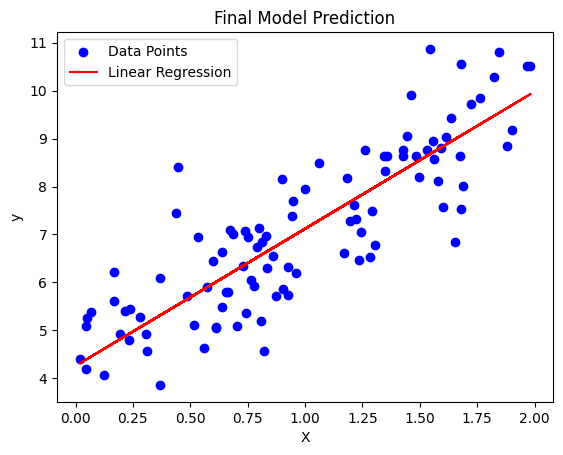

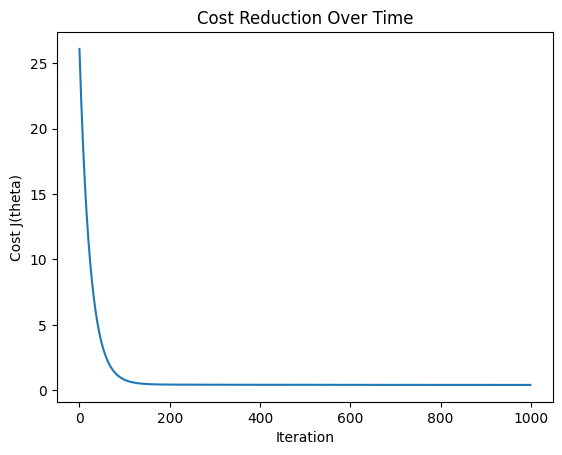

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('../src/')
from linear_regression import gradient_descent

def main():
  # r = 100, n = 2 including the one vector.
  # Definition of Variables.
  X = 2 * np.random.rand(100, 1)
  y = 4 + 3*X + np.random.randn(100,1)
  # (X*theta_0 - y)
  X_b = np.c_[(np.ones((100, 1)), X)]
  theta_0 = np.random.randn(2, 1)
  alpha = 0.01
  iterations = 1000

  theta_final, costs = gradient_descent(X_b, y, theta_0, alpha, iterations)
  plt.scatter(X, y, color='blue', label='Data Points')
  plt.plot(X, X_b.dot(theta_final), color='red', label='Linear Regression')
  plt.xlabel('X')
  plt.ylabel('y')
  plt.legend()
  plt.title('Final Model Prediction')
  plt.show()

  plt.plot(costs)
  plt.xlabel('Iteration')
  plt.ylabel('Cost J(theta)')
  plt.title('Cost Reduction Over Time')
  plt.show()

if __name__ == "__main__":
  main()


  Lecture: The Architect - From NumPy Arrays to PyTorch Tensors

  You have now built a model from first principles using NumPy, manually calculating the gradient at each step. This is the bedrock. However, for complex models with millions of parameters
  (e.g., Deep Neural Networks), manual derivation of the gradient is intractable and error-prone.


  This is where frameworks like PyTorch introduce automatic differentiation.


  The core data structure in PyTorch is the torch.Tensor, which is analogous to a NumPy ndarray. The critical difference is that a Tensor can be tracked by PyTorch's autograd engine. By
  setting requires_grad=True on a Tensor, you instruct PyTorch to build a computation graph. This graph records every operation performed on the tensor.


  When you call .backward() on a scalar value derived from this graph (typically, the final loss), autograd traverses this graph in reverse, computing the gradients of that scalar with
  respect to all tensors that have requires_grad=True using the chain rule. The computed gradients are then accumulated in the .grad attribute of each tensor.


  For our Linear Regression, instead of manually computing:
  $$\nabla_{\theta} J(\theta) = \frac{1}{m} X^T (X\theta - y)$$
  ...we will define the forward pass and the cost function using Tensors, and simply call loss.backward(). PyTorch will handle the rest.

  ---

  Assignment: The First-Principles Implementation in PyTorch


  You are now to re-implement your Linear Regression model using PyTorch, but without using the high-level `torch.nn` or `torch.optim` modules. You must still build it from the ground up,
  but this time leveraging autograd.


  The Hard Coding Challenge:
  In a new file, deep_learning_labs/labs/lab01_foundations/src/pytorch_regression.py, implement the following:
   1. Use the same synthetic data, but convert X and y into torch.Tensor objects.
   2. Initialize your theta tensor randomly. Crucially, it must be initialized with requires_grad=True.
   3. In your training loop:
      a.  Calculate the prediction y_hat.
      b.  Calculate the MSE loss.
      c.  Call loss.backward() to populate the gradients in theta.grad.
      d.  Manually update the weights of `theta` using the formula: theta.data -= alpha * theta.grad.data. You must use .data (or torch.no_grad()) to prevent this update operation from
  being tracked by autograd.
      e.  Zero out the gradients (theta.grad.zero_()) before the next iteration. Gradients are accumulated by default.
   4. Create a corresponding notebook to import this new module and, once again, plot the cost history to verify convergence.